In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_ripplAI.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 2250 rows from spikes\all_networks_metrics_ripplAI.csv
Columns: ['Session', 'Channel', 'Threshold', 'Model', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples']
Threshold: [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


,Session,Channel,Threshold,Model,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples
0,2025-09-22_17-42-27,24,0.3,CNN1D_1,80,68,29,0.540541,0.733945,0.622568,14.054167,170,109
1,2025-09-22_17-42-27,24,0.3,CNN1D_2,36,1,73,0.972973,0.330275,0.493151,17.206481,37,109
2,2025-09-22_17-42-27,24,0.3,CNN1D_3,63,12,46,0.840000,0.577982,0.684783,12.385714,75,109
3,2025-09-22_17-42-27,24,0.3,CNN1D_4,56,10,53,0.848485,0.513761,0.640000,16.235714,67,109
4,2025-09-22_17-42-27,24,0.3,CNN1D_5,74,60,35,0.552239,0.678899,0.609053,7.547748,138,109


In [4]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions
df = df[~df["Session"].isin(hfo_sessions)]



# og_session_set={"2025-09-22_17-55-26", #R
#                 "2025-09-23_15-50-26", #R
#                 "2025-09-24_10-24-40", #R
#                 "2025-09-24_14-22-55", #H
#                 "2025-09-24_15-13-10", #H
#                 "2025-09-25_16-41-14"} #R
# df=df[df["Session"].isin(og_session_set)]

# # New sessions:
session_set={"2025-09-24_16-29-07", #R   
        "2025-09-24_17-38-17",
        "2025-09-25_12-52-22",
        "2025-09-24_11-34-51",
        } #R 
df=df[~df["Session"].isin(session_set)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-22_17-42-27' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-23_16-17-52' '2025-09-24_10-24-40' '2025-09-25_16-41-14'
 '2025-09-25_11-21-53']


In [5]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
0.3,0.371,0.528,0.417,55.767,88.627,67.733
0.4,0.354,0.592,0.339,48.617,49.343,86.097
0.5,0.317,0.613,0.275,39.417,29.126,95.297
0.6,0.275,0.642,0.219,31.394,17.063,103.320
0.7,0.231,0.614,0.168,24.286,9.154,110.429
0.8,0.180,0.556,0.120,17.343,3.943,117.371
0.9,0.120,0.537,0.073,10.509,1.171,124.206


In [7]:
df['Model'] = df['Model'].str.extract(r'(CNN1D|CNN2D|LSTM|SVM|XGBOOST)', expand=False)
# Print summary by Threshold and Model
print("\n--- Summary by Threshold and Model ---")
summary = df.groupby(['Threshold', 'Model'])[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3)
display(summary)


--- Summary by Threshold and Model ---


F1  Precision  Recall      TP       FP       FN
Threshold Model                                                      
0.3       CNN1D    0.402      0.661   0.346  47.333   27.233   76.167
          CNN2D    0.259      0.682   0.197  26.633   14.967   96.867
          LSTM     0.441      0.631   0.385  53.100   23.200   70.400
          SVM      0.353      0.363   0.483  62.300  160.700   61.200
          XGBOOST  0.399      0.305   0.676  89.467  217.033   34.033
0.4       CNN1D    0.358      0.686   0.280  41.200   17.086   93.514
          CNN2D    0.233      0.695   0.171  26.400   15.314  108.314
          LSTM     0.384      0.705   0.291  42.743    9.686   91.971
          SVM      0.325      0.466   0.338  44.257   76.371   90.457
          XGBOOST  0.470      0.409   0.618  88.486  128.257   46.229
0.5       CNN1D    0.312      0.707   0.227  33.571   10.114  101.143
          CNN2D    0.169      0.626   0.115  18.000    6.971  116.714
          LSTM     0.317      0.737   0.223  33.000    4.343  101.714
          SVM      0.300      0.516   0.266  34.600   43.914  100.114
          XGBOOST  0.487      0.479   0.544  77.914   80.286   56.800
0.6       CNN1D    0.265      0.733   0.183  27.029    6.286  107.686
          CNN2D    0.123      0.599   0.084  13.286    4.257  121.429
          LSTM     0.246      0.727   0.163  24.200    1.657  110.514
          SVM      0.259      0.604   0.197  25.571   24.143  109.143
          XGBOOST  0.481      0.545   0.466  66.886   48.971   67.829
0.7       CNN1D    0.214      0.695   0.140  20.600    3.514  114.114
          CNN2D    0.101      0.521   0.069  10.857    3.057  123.857
          LSTM     0.173      0.650   0.109  16.229    0.400  118.486
          SVM      0.211      0.579   0.142  18.429   12.429  116.286
          XGBOOST  0.455      0.624   0.382  55.314   26.371   79.400
0.8       CNN1D    0.161      0.693   0.100  14.657    1.771  120.057
          CNN2D    0.086      0.371   0.057   8.886    2.400  125.829
          LSTM     0.097      0.384   0.060   8.743    0.229  125.971
          SVM      0.162      0.615   0.097  12.771    5.543  121.943
          XGBOOST  0.396      0.718   0.285  41.657    9.771   93.057
0.9       CNN1D    0.100      0.641   0.059   8.629    0.629  126.086
          CNN2D    0.070      0.369   0.044   6.829    1.200  127.886
          LSTM     0.046      0.257   0.027   3.971    0.000  130.743
          SVM      0.106      0.618   0.059   7.714    1.457  127.000
          XGBOOST  0.276      0.799   0.174  25.400    2.571  109.314

In [7]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.489
Precision     0.501
Recall        0.574
TP           57.818
FP           57.182
FN           43.727
Name: 6.0, dtype: float64


In [8]:
# Print summary
print("\n--- Summary by Session ---")
summary = df.groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Session ---


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
2025-09-22_17-55-26,0.646,0.750,0.624,115.500,67.833,69.500
2025-09-23_15-50-26,0.601,0.608,0.668,92.833,102.333,46.167
2025-09-25_11-21-53,0.536,0.620,0.541,109.333,108.833,92.667
2025-09-25_16-41-14,0.508,0.549,0.560,80.667,106.667,63.333
2025-09-24_10-24-40,0.463,0.438,0.621,57.167,156.667,34.833
2025-09-22_17-42-27,0.402,0.447,0.489,53.333,139.167,55.667
2025-09-23_16-17-52,0.399,0.357,0.613,44.167,178.000,27.833
2025-09-24_11-34-51,0.324,0.439,0.399,28.333,90.667,42.667
2025-09-24_16-29-07,0.294,0.222,0.617,24.667,177.333,15.333


In [9]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\79562911.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)


N=11 matched samples for statistics.
3.0 vs 4.0: p=0.0010
3.0 vs 5.0: p=0.0010
3.0 vs 6.0: p=0.0010
3.0 vs 7.0: p=0.0010
3.0 vs 8.0: p=0.0010
4.0 vs 5.0: p=0.0010
4.0 vs 6.0: p=0.0010
4.0 vs 7.0: p=0.0010


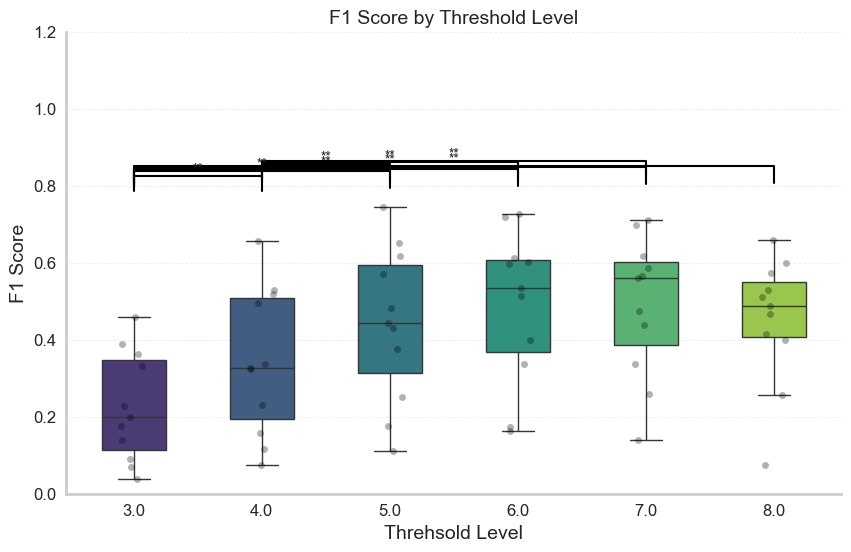

In [10]:
def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                if p < 0.05:
                    print(f"{a1} vs {a2}: p={p:.4f}")
                    barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
    
    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)           
    ax.set_title(f"{metric} Score by Threshold Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.2) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threhsold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()

if 'df' in locals():
    plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False)

C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\3083535743.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\3083535743.py:23: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


3.0 vs 4.0: p=0.0010
3.0 vs 5.0: p=0.0010
3.0 vs 6.0: p=0.0010
3.0 vs 7.0: p=0.0010
3.0 vs 8.0: p=0.0010
4.0 vs 5.0: p=0.0010
4.0 vs 6.0: p=0.0010
4.0 vs 7.0: p=0.0010
4.0 vs 8.0: p=0.1230
5.0 vs 6.0: p=0.0674
5.0 vs 7.0: p=0.2783
5.0 vs 8.0: p=1.0000
6.0 vs 7.0: p=0.8311
6.0 vs 8.0: p=0.3203
7.0 vs 8.0: p=0.0830


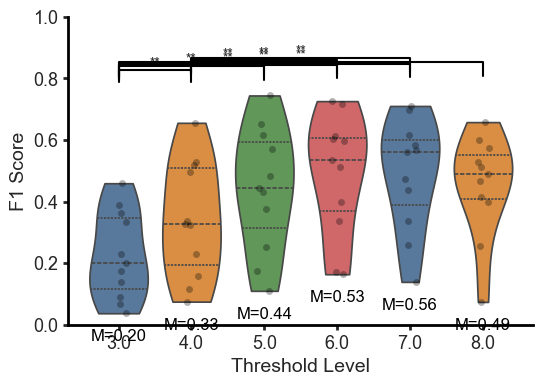

In [11]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
        
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


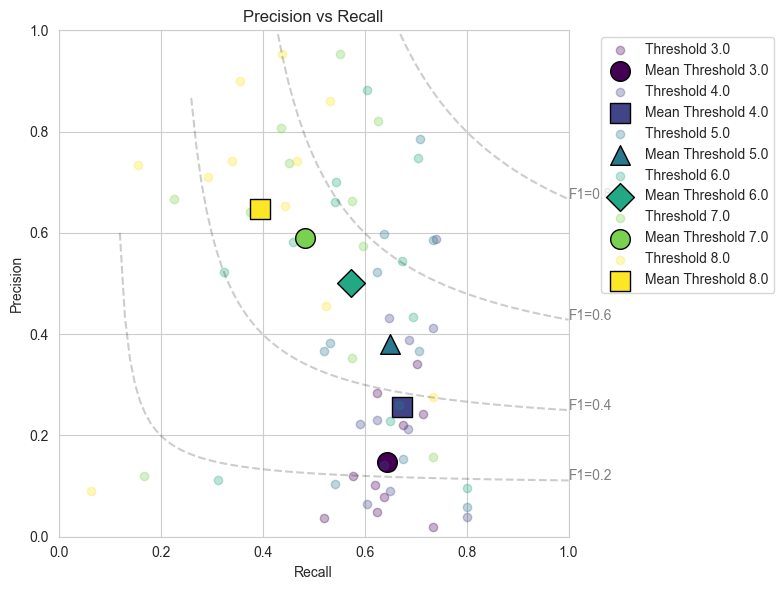

In [12]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\2763784449.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)


UnboundLocalError: local variable 'boxprops' referenced before assignment

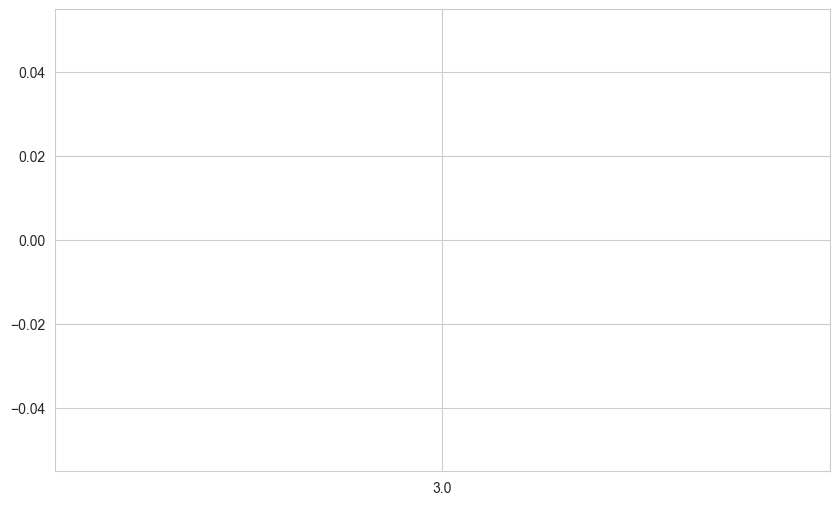

In [13]:
def plot_relative_change(df, metric="F1"):
    # Pivot to have Adapt as columns
    pivot_cols = ["Session", "Channel",]
    if "Dataset" in df.columns:
        pivot_cols.append("Dataset")
        
    pivot = df.pivot_table(index=pivot_cols, columns="Threshold", values=metric) # Pivot table
    # print(pivot.head())
    # Calculate change relative to Adapt 0 (or lowest adapt value)
     # Define specific order
    desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values= sorted(df["Threshold"].unique())
    baseline_adapt = 3.0
    
    if baseline_adapt not in pivot.columns:
        print(f"Baseline adapt {baseline_adapt} not found in pivot columns.")
        return

    changes = pd.DataFrame()
    for col in pivot.columns:
        changes[col] = (pivot[col] - pivot[baseline_adapt]) / pivot[baseline_adapt] * 100
        
    # Melt for plotting
    melted = changes.melt(var_name="Threshold", value_name="Percent Change")
    # print(melted)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x="Threshold", y="Percent Change", data=melted, palette="coolwarm", order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y="Percent Change", data=melted, color="black", alpha=0.3, jitter=True, order=adapt_values)

    plt.axhline(0, color='black', linestyle='--')
    plt.title(f"Relative Change in {metric} (%) compared to Threshold {baseline_adapt}")
    plt.ylabel(f"% Change in {metric}")
    plt.show()

if 'df' in locals():
    plot_relative_change(df, "F1")

,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-55-26,26,5.0,Precision,0.784431
1,2025-09-25_11-21-53,21,5.0,Precision,0.597222
2,2025-09-22_17-42-27,24,5.0,Precision,0.381579
3,2025-09-25_12-52-22,25,5.0,Precision,0.104839
4,2025-09-24_11-34-51,30,5.0,Precision,0.366337


C:\Users\NCN\AppData\Local\Temp\ipykernel_15644\258087946.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


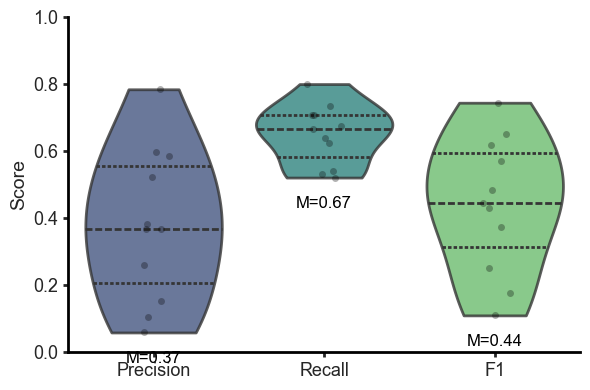

In [14]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=5.0, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)